In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [51]:
archivo = "../data/raw/sales.csv"
df = pd.read_csv(archivo)
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


In [52]:
df.dtypes

date      object
sales    float64
dtype: object

In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

In [55]:
df.dtypes

date     datetime64[ns]
sales           float64
dtype: object

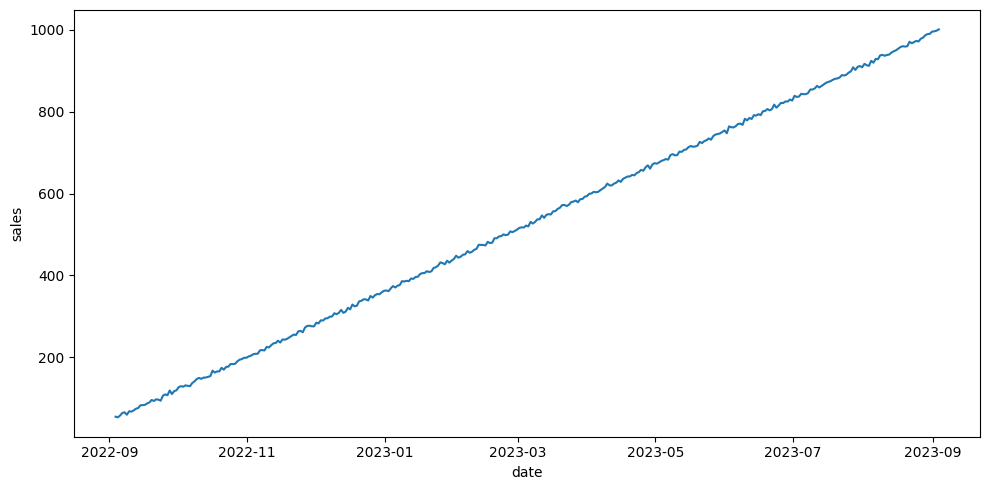

In [56]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data=df, x="date", y="sales")

plt.tight_layout()

plt.show()

## ¿Cuál es la tendencia?

>Verificaremos el tipo de tendencia

In [57]:
decomposition = seasonal_decompose(df["sales"], period = 30)
decomposition

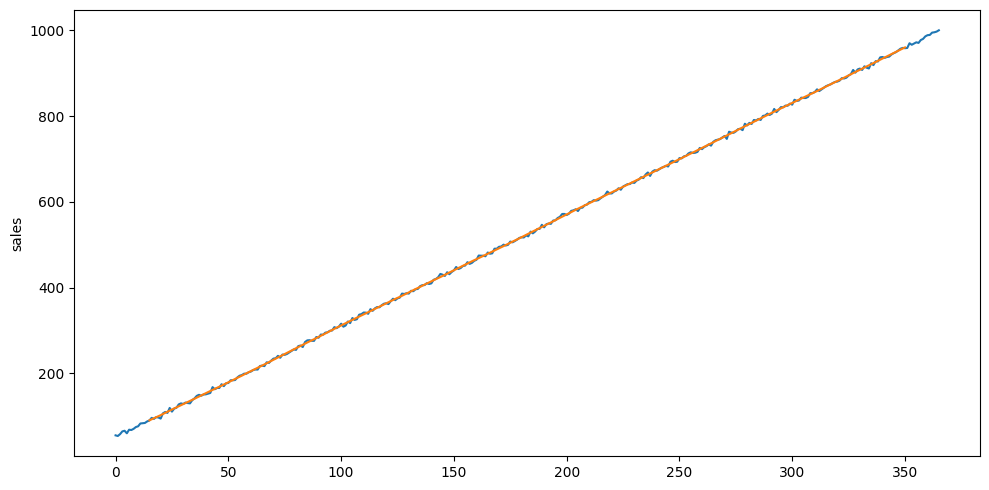

In [58]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df["sales"])
sns.lineplot(data = trend)

plt.tight_layout()

plt.show()

### Observaciones.

tenemos una clara tendencia alcista.

## ¿Cuál es el tensor de la serie temporal?

>para ello analizaremos los datos y definiremos que tiempo pasa entre uno y otro.

In [59]:
ts = df.set_index("date")["sales"].astype(float).to_numpy()   
tensor = ts.reshape(-1, 1)                                   
tensor.shape

(366, 1)

In [60]:
df["date"].min(), df["date"].max()

(Timestamp('2022-09-03 17:10:08.079328'),
 Timestamp('2023-09-03 17:10:08.079328'))

### Observaciones

>Viendo los datos tenemos 366 dias y las fechas min y max son coherentes a un dia por dato. 

## ¿Es estacionaria?

> Para eso analizaremos el grafico. 

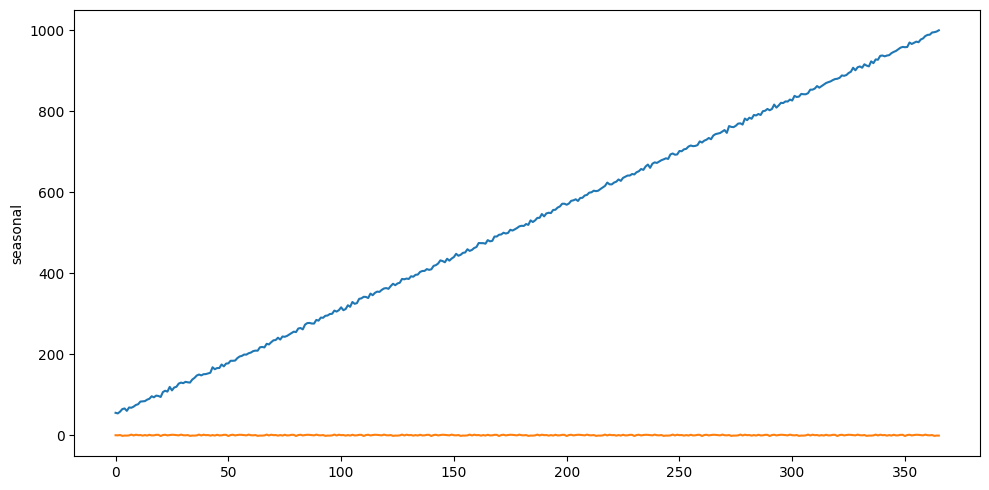

In [61]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

In [62]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(ts)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

## Observaciones

>Aquí podemos ver que el p-value es mayor a 0.05, esto significa que nuestra hipótesis nula no será rechazada y tomaremos esta serie como no estacionaria.

## ¿Existe variabilidad o presencia de ruido?

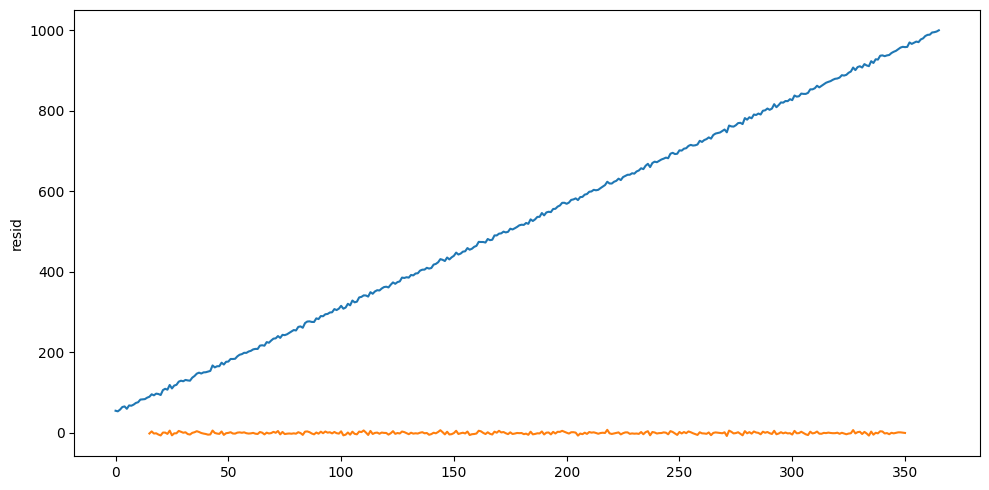

In [63]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

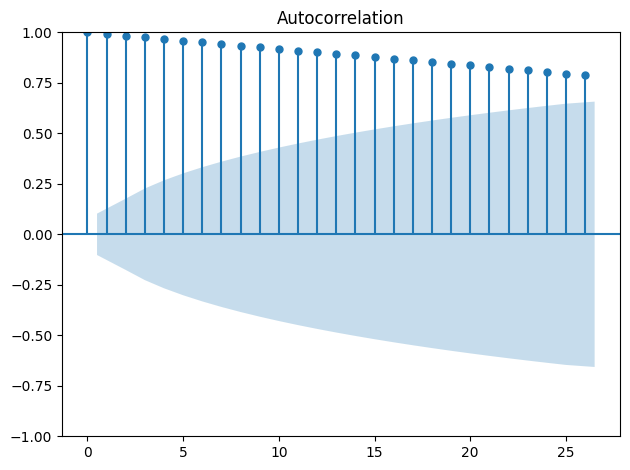

In [64]:
plot_acf(ts)

plt.tight_layout()

plt.show()

### Observaciones

> Podemos predecir hasta un periodo aproximado de 30 dias

## Modelo Arima

In [65]:
ts = df.set_index("date")["sales"].astype(float)
train = ts[:-30]  # Todo excepto últimos 30 días
test = ts[-30:]   # Últimos 30 días para evaluar

# Diferenciar solo train
train_stationary = train.diff().dropna()

# Entrenar con train
model = auto_arima(train_stationary, seasonal=True, m=7)

# Predecir los 30 días de test
forecast = model.predict(30)

In [66]:
last_value = ts.iloc[-1]
forecast_original_scale = forecast.cumsum() + last_value

In [67]:
ts = df.set_index("date")["sales"].astype(float)
ts_stationary = ts.diff().dropna()

test_stationarity(ts_stationary)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

In [68]:
model = auto_arima(ts_stationary, seasonal=True, m=7, trace=True)
model_sin_diff = auto_arima(ts, seasonal=True, m=7, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.65 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=2096.542, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=1966.396, Time=0.15 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=2209.657, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=1970.972, Time=0.04 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=1968.120, Time=0.41 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=1968.220, Time=0.36 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=1966.919, Time=0.07 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=1965.376, Time=0.66 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=1965.211, Time=0.94 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=1963.937, Time=0.66 sec
 ARIMA(1,0,0)(0,0,2)[7] intercept   : AIC=1967.822, Time=0.24 sec
 ARIMA(0,0,0)(1,0,2)[7] intercept   : AIC=2094.918, Time=0.54 sec
 ARIMA(2,0,0)(1,0,2)[7] intercept   : AIC=1

In [69]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                                      y   No. Observations:                  365
Model:             SARIMAX(2, 0, 1)x(1, 0, [1, 2], 7)   Log Likelihood                -910.863
Date:                                Tue, 24 Feb 2026   AIC                           1837.726
Time:                                        02:19:58   BIC                           1868.925
Sample:                                    09-04-2022   HQIC                          1850.125
                                         - 09-03-2023                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.1892      0.477     10.869      0.000       4.253       6.125
ar.L1         -0.0774      0.054     -1.436      0.151      -0.183       0.028
ar.L2          0.0539      0.059      0.918      0.359      -0.061       0.169
ma.L1         -0.9773      0.018    -55.002      0.000      -1.012      -0.942
ar.S.L7       -0.9504      0.075    -12.606      0.000      -1.098      -0.803
ma.S.L7        1.1090      0.092     12.025      0.000       0.928       1.290
ma.S.L14       0.1809      0.054      3.358      0.001       0.075       0.286
sigma2         8.6913      0.697     12.474      0.000       7.326      10.057
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                 0.17
Prob(Q):                              0.77   Prob(JB):                         0.92
Heteroskedasticity (H):               0.87   Skew:                             0.04
Prob(H) (two-sided):                  0.46   Kurtosis:                         2.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [70]:
model_sin_diff.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  366
Model:             SARIMAX(4, 1, 1)x(0, 0, 1, 7)   Log Likelihood                -912.372
Date:                           Tue, 24 Feb 2026   AIC                           1840.744
Time:                                   02:19:58   BIC                           1871.943
Sample:                               09-03-2022   HQIC                          1853.143
                                    - 09-03-2023                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.8853      0.378      7.634      0.000       2.145       3.626
ar.L1         -0.0805      0.054     -1.500      0.134      -0.186       0.025
ar.L2          0.0168      0.063      0.269      0.788      -0.106       0.139
ar.L3          0.0242      0.058      0.414      0.679      -0.090       0.139
ar.L4         -0.0713      0.053     -1.351      0.177      -0.175       0.032
ma.L1         -0.9393      0.026    -36.334      0.000      -0.990      -0.889
ma.S.L7        0.1039      0.053      1.944      0.052      -0.001       0.209
sigma2         8.4131      0.658     12.789      0.000       7.124       9.702
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.95
Prob(Q):                              0.95   Prob(JB):                         0.62
Heteroskedasticity (H):               0.91   Skew:                             0.07
Prob(H) (two-sided):                  0.59   Kurtosis:                         2.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [71]:
day_to_predict = 7
forecast = model.predict(day_to_predict)
forecast_sin_diff = model_sin_diff.predict(day_to_predict)
forecast

2023-09-04 17:10:08.079328    2.082317
2023-09-05 17:10:08.079328    3.051095
2023-09-06 17:10:08.079328    1.940035
2023-09-07 17:10:08.079328    3.235950
2023-09-08 17:10:08.079328    1.729522
2023-09-09 17:10:08.079328    3.064951
2023-09-10 17:10:08.079328    2.353270
Freq: D, dtype: float64

In [72]:
forecast_sin_diff

2023-09-04 17:10:08.079328    1002.221618
2023-09-05 17:10:08.079328    1005.067987
2023-09-06 17:10:08.079328    1007.539800
2023-09-07 17:10:08.079328    1010.356685
2023-09-08 17:10:08.079328    1012.902669
2023-09-09 17:10:08.079328    1015.324514
2023-09-10 17:10:08.079328    1017.970064
Freq: D, dtype: float64

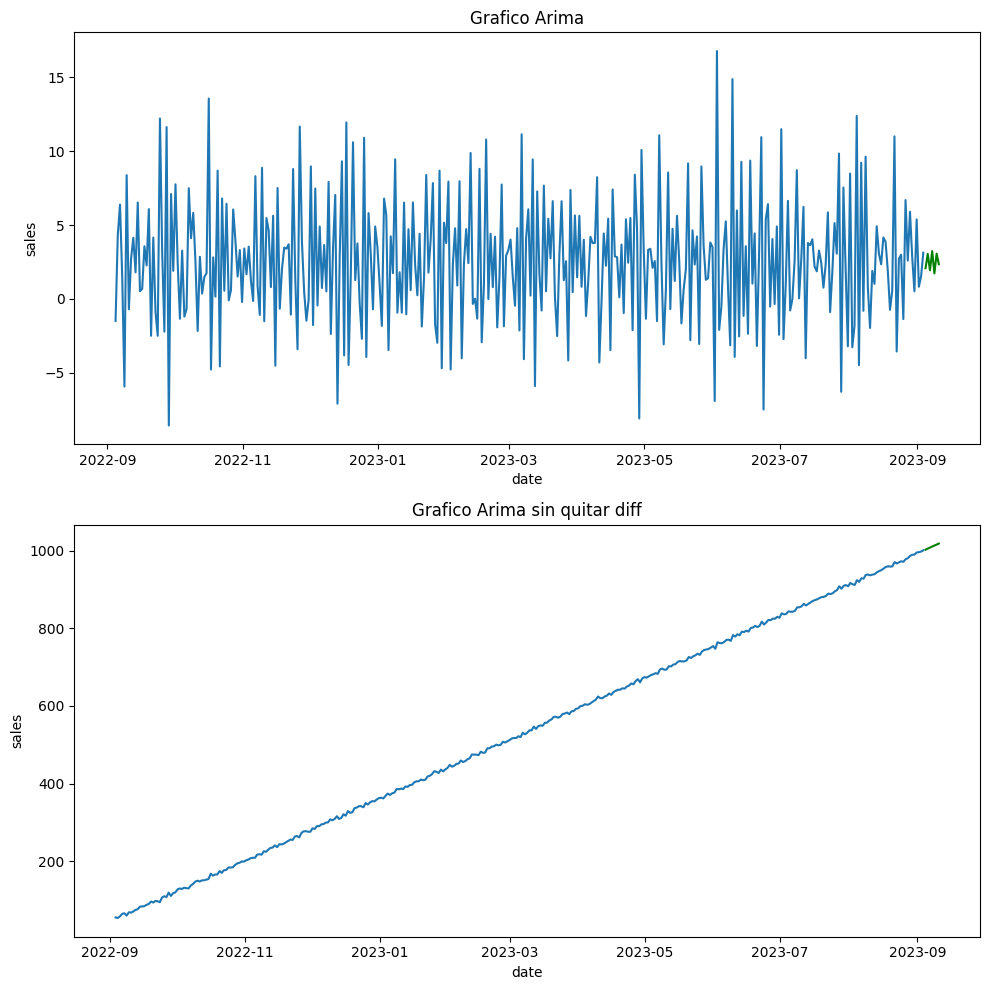

In [73]:
fig, axis = plt.subplots(2, 1, figsize=(10, 10))

sns.lineplot(ax=axis[0], data=ts_stationary).set(title="Grafico Arima")
sns.lineplot(ax=axis[0], data=forecast, c="green")
sns.lineplot(ax=axis[1], data=ts).set(title="Grafico Arima sin quitar diff")
sns.lineplot(ax=axis[1], data=forecast_sin_diff, c="green")

plt.tight_layout()

plt.show()

In [ ]:
mae = mean_absolute_error(test, forecast_original_scale)
rmse = np.sqrt(mean_squared_error(test, forecast_original_scale))
mape = np.mean(np.abs((test - forecast_original_scale) / test)) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 76.53
RMSE: 76.57
MAPE: 7.96%


In [76]:
import pickle

with open("../models/arima_sales.pkl", "wb") as f:
    pickle.dump(model, f)

## Conclusiones

> Podemos ver que gracias al Arima podemos predecir los graficos a futuro.
>
>En el primer grafico aunque no pareciera una constante clara podemos visualizar que los valores de `Sales` estan entre -5 y 15 aproximadamente. Se crea una prediccion de 10 dias que parece no seguir un patrón claro.
>
>En el segundo gráfico los visualizamos sin Diff y notamos que sigue el patron de conducta que llevaba anteriormente.